<span style="font-size: 5em">🏠</span>

# __Airbnb Multi-City Analysis Agent__
## Build Agentic AI for Real-World Data Workflows

<div style="background: linear-gradient(135deg, #FF5A5F 0%, #00A699 100%); padding: 20px; border-radius: 10px; color: white; margin: 20px 0; border-left: 4px solid #484848;">
    <h3 style="margin: 0; color: white;">🎯 What You'll Build</h3>
    <p>An agent that <strong>automatically cleans data</strong> based on your preferences, then <strong>autonomously decides</strong> what analytics to generate — and applies this across <strong>multiple cities</strong>.</p>
</div>

---

## 🤔 The Workflow

```
┌─────────────────┐     ┌─────────────────┐     ┌─────────────────┐     ┌─────────────────┐
│   Amsterdam     │     │     Athens      │     │   Barcelona     │     │     Berlin      │
│   listings.csv  │     │   listings.csv  │     │   listings.csv  │     │   listings.csv  │
└────────┬────────┘     └────────┬────────┘     └────────┬────────┘     └────────┬────────┘
         │                       │                       │                       │
         └───────────────────────┴───────────────────────┴───────────────────────┘
                                           │
                                           ▼
                                 ┌─────────────────┐
                                 │  detect_issues  │ ← First city: Find issues
                                 └────────┬────────┘
                                          │
                                          ▼
                                 ┌─────────────────┐
                                 │ ask_preferences │ ← 🛑 INTERRUPT (only once!)
                                 └────────┬────────┘
                                          │
                                          ▼
                                 ┌─────────────────┐
                                 │   clean_all     │ ← Apply to ALL cities
                                 └────────┬────────┘
                                          │
                                          ▼
                                 ┌─────────────────┐
                                 │  decide_task    │ ← LLM decides what to analyze!
                                 └────────┬────────┘
                                          │
                                          ▼
                                 ┌─────────────────┐
                                 │execute_analysis │ ← Generates insights
                                 └────────┬────────┘
                                          │
                                          ▼
                                 ┌─────────────────┐
                                 │decide_visualize │ ← LLM picks best viz!
                                 └────────┬────────┘
                                          │
                                          ▼
                                 ┌─────────────────┐
                                 │create_visualize │ ← Generates chart
                                 └────────┬────────┘
                                          │
                                          ▼
                                        END
```

**The key innovations:**
1. Ask preferences ONCE, apply to ALL cities
2. LLM autonomously decides what analytics to create based on the data
3. LLM decides the most impactful visualization for your audience

---
## Part 0: Setup & Environment Check

In [89]:
# 🔧 SETUP CHECK - Run this cell first!
import sys
print(f"✅ Python version: {sys.version}")

# Check required packages
required = ["langgraph", "langchain", "langchain_openai", "pandas", "matplotlib", "seaborn"]
missing = []

for pkg in required:
    try:
        __import__(pkg.replace("-", "_"))
        print(f"✅ {pkg} installed")
    except ImportError:
        missing.append(pkg)
        print(f"❌ {pkg} missing")

if missing:
    print(f"\n🔴 Install missing packages: pip install {' '.join(missing)}")
else:
    print("\n🟢 All packages ready!")

✅ Python version: 3.12.12 (main, Oct  9 2025, 11:07:00) [Clang 17.0.0 (clang-1700.6.3.2)]
✅ langgraph installed
✅ langchain installed
✅ langchain_openai installed
✅ pandas installed
✅ matplotlib installed
✅ seaborn installed

🟢 All packages ready!


In [90]:
# 📦 Import everything we need
import uuid
import json
import operator
import os
import base64
from io import BytesIO
from pathlib import Path
from typing import Annotated, Literal, TypedDict
from IPython.display import Image, display, Markdown

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from langgraph.checkpoint.sqlite import SqliteSaver

print("✅ All imports successful!")

✅ All imports successful!


In [91]:
# 🔑 LLM Setup (using AWS Bedrock - modify for OpenAI if needed)
from dotenv import load_dotenv
import boto3
from botocore.config import Config
from botocore import UNSIGNED
from langchain_aws import ChatBedrockConverse

load_dotenv()

token = os.environ.get("AWS_BEARER_TOKEN_BEDROCK")

bedrock_client = boto3.client(
    "bedrock-runtime",
    region_name="us-east-1",
    config=Config(signature_version=UNSIGNED),
)

def add_bearer_token(request, **kwargs):
    request.headers["Authorization"] = f"Bearer {token}"

bedrock_client.meta.events.register("before-send.bedrock-runtime.*", add_bearer_token)

llm = ChatBedrockConverse(
    model="us.anthropic.claude-sonnet-4-20250514-v1:0",
    client=bedrock_client,
)

# Quick test
response = llm.invoke("Say 'Ready to analyze Airbnb data!' in exactly 5 words.")
print(f"✅ LLM connected: {response.content}")

✅ LLM connected: Ready to analyze Airbnb data!


---
## Part 1: Explore the Airbnb Data

We have data from **4 European cities**: Amsterdam, Athens, Barcelona, Berlin

In [92]:
# 📂 Discover available data
AIRBNB_DATA_PATH = Path("../Airbnb")

cities = [d.name for d in AIRBNB_DATA_PATH.iterdir() if d.is_dir()]
print(f"🏙️ Available cities: {cities}")

# Check what files exist for each city
for city in cities:
    city_path = AIRBNB_DATA_PATH / city
    files = list(city_path.glob("*.csv*"))
    print(f"\n📁 {city}:")
    for f in files:
        print(f"   • {f.name}")

🏙️ Available cities: ['Barcelona', 'Berlin', 'Athens']

📁 Barcelona:
   • reviews.csv
   • listings.csv

📁 Berlin:
   • reviews.csv
   • listings.csv

📁 Athens:
   • reviews.csv
   • listings.csv


In [93]:
# 👀 Preview the listings data structure
sample_df = pd.read_csv(AIRBNB_DATA_PATH / "Barcelona" / "listings.csv", nrows=5)
print(f"📊 Listings has {len(sample_df.columns)} columns!\n")
print("Key columns:")

important_cols = [
    'id', 'name', 'host_name', 'neighbourhood_cleansed', 'property_type', 
    'room_type', 'accommodates', 'bedrooms', 'beds', 'price',
    'review_scores_rating', 'number_of_reviews', 'availability_365'
]

for col in important_cols:
    if col in sample_df.columns:
        print(f"   • {col}: {sample_df[col].iloc[0]}")

📊 Listings has 18 columns!

Key columns:
   • id: 18674
   • name: Huge flat for 8 people close to Sagrada Familia
   • host_name: Mireia
   • room_type: Entire home/apt
   • price: 210
   • number_of_reviews: 51
   • availability_365: 80


---
## Part 2: Define the Multi-City Agent State

We need to track:
- **Multiple datasets** (one per city)
- **Shared preferences** (ask once, apply everywhere)
- **Analysis task** (LLM decides what to do)
- **Results per city**

In [94]:
# 🔍 Issue and Preference structures
class DetectedIssue(TypedDict):
    """A single detected data quality issue"""
    issue_type: Literal["missing_values", "price_format", "text_inconsistency", "outliers", "date_format"]
    column: str
    description: str
    examples: list[str]
    options: list[str]
    severity: Literal["high", "medium", "low"]


class UserPreference(TypedDict):
    """User's choice for handling an issue"""
    issue_type: str
    column: str
    choice: str


class CityData(TypedDict):
    """Data for a single city"""
    city_name: str
    raw_data: str  # CSV string
    cleaned_data: str | None
    row_count: int


class AnalysisTask(TypedDict):
    """The task the LLM decided to perform"""
    task_name: str
    task_description: str
    required_columns: list[str]
    analysis_type: Literal["comparison", "ranking", "trends", "segmentation", "pricing"]


class VisualizationTask(TypedDict):
    """The visualization the LLM decided to create"""
    viz_type: Literal["bar", "grouped_bar", "scatter", "heatmap", "boxplot", "pie"]
    title: str
    description: str
    x_data: str  # Column or aggregation for x-axis
    y_data: str  # Column or aggregation for y-axis
    group_by: str | None  # Optional grouping
    rationale: str  # Why this visualization is impactful for the audience


# 📊 The full agent state
class AirbnbAnalysisState(TypedDict):
    # Input
    cities_to_analyze: list[str]
    
    # Data Storage
    city_datasets: dict[str, CityData]  # city_name -> data
    
    # Issue Detection (from first city, applies to all)
    detected_issues: list[DetectedIssue] | None
    
    # User Preferences — SHARED ACROSS ALL CITIES!
    user_preferences: list[UserPreference]
    preferences_collected: bool
    
    # Cleaning Results
    cleaning_actions: Annotated[list[str], operator.add]
    
    # LLM-Decided Task
    analysis_task: AnalysisTask | None
    
    # LLM-Decided Visualization
    visualization_task: VisualizationTask | None
    visualization_figure: str | None  # Base64 encoded image
    
    # Final Results
    analysis_results: dict | None
    insights: list[str] | None
    summary: str | None


print("✅ State schema defined!")
print("\n📋 Key concepts:")
print("   • city_datasets — Data for each city")
print("   • user_preferences — YOUR choices (applied to ALL cities!)")
print("   • analysis_task — LLM decides what analytics to generate")
print("   • visualization_task — LLM decides the most impactful visualization")

✅ State schema defined!

📋 Key concepts:
   • city_datasets — Data for each city
   • user_preferences — YOUR choices (applied to ALL cities!)
   • analysis_task — LLM decides what analytics to generate
   • visualization_task — LLM decides the most impactful visualization


---
## Part 3: Build the Agent Nodes

### Node 1: Load Data from Multiple Cities

In [95]:
def load_city_data(state: AirbnbAnalysisState) -> AirbnbAnalysisState:
    """Load listings data from all specified cities."""
    print("📂 Loading Airbnb data from multiple cities...")
    
    city_datasets = {}
    
    # Select important columns to keep memory manageable
    KEEP_COLUMNS = [
        'id', 'name', 'host_name', 'host_since', 'host_response_rate',
        'host_is_superhost', 'neighbourhood_cleansed', 'latitude', 'longitude',
        'property_type', 'room_type', 'accommodates', 'bedrooms', 'beds',
        'price', 'minimum_nights', 'maximum_nights',
        'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness',
        'review_scores_location', 'review_scores_value',
        'availability_30', 'availability_365', 'instant_bookable'
    ]
    
    for city in state["cities_to_analyze"]:
        city_path = AIRBNB_DATA_PATH / city / "listings.csv"
        
        if city_path.exists():
            df = pd.read_csv(city_path, usecols=lambda c: c in KEEP_COLUMNS)
            df['city'] = city  # Add city column
            
            city_datasets[city] = {
                "city_name": city,
                "raw_data": df.to_csv(index=False),
                "cleaned_data": None,
                "row_count": len(df)
            }
            print(f"   ✓ {city}: {len(df):,} listings loaded")
        else:
            print(f"   ⚠ {city}: File not found")
    
    return {"city_datasets": city_datasets}

### Node 2: Detect Issues (from first city — applies to all)

In [96]:
def detect_issues(state: AirbnbAnalysisState) -> AirbnbAnalysisState:
    """Detect data quality issues using the first city as reference."""
    print("\n🔍 Scanning data for issues that need your input...")
    
    first_city = list(state["city_datasets"].keys())[0]
    df = pd.read_csv(pd.io.common.StringIO(state["city_datasets"][first_city]["raw_data"]))
    
    issues: list[DetectedIssue] = []
    
    # 1. PRICE FORMAT (often has $ sign and commas)
    if 'price' in df.columns:
        sample_prices = df['price'].dropna().head(5).tolist()
        has_currency = any('$' in str(p) for p in sample_prices)
        
        if has_currency:
            issues.append({
                "issue_type": "price_format",
                "column": "price",
                "description": "Prices contain currency symbols and formatting",
                "examples": [str(p) for p in sample_prices[:3]],
                "options": ["Convert to numeric (remove $ and commas)", "Keep as text"],
                "severity": "high"
            })
    
    # 2. MISSING VALUES
    important_cols = ['bedrooms', 'beds', 'review_scores_rating', 'host_response_rate']
    
    for col in important_cols:
        if col in df.columns:
            missing_count = int(df[col].isnull().sum())
            missing_pct = (missing_count / len(df)) * 100
            
            if missing_pct > 5:
                is_numeric = df[col].dtype in ['int64', 'float64']
                
                if is_numeric:
                    options = ["Fill with median", "Fill with 0", "Drop rows with missing", "Leave empty"]
                else:
                    options = ["Fill with 'Unknown'", "Fill with most common", "Drop rows", "Leave empty"]
                
                issues.append({
                    "issue_type": "missing_values",
                    "column": col,
                    "description": f"{missing_pct:.1f}% missing values ({missing_count:,} rows)",
                    "examples": [f"{missing_count:,} out of {len(df):,} rows"],
                    "options": options,
                    "severity": "high" if missing_pct > 20 else "medium"
                })
    
    # 3. SUPERHOST FLAG (t/f to boolean)
    if 'host_is_superhost' in df.columns:
        sample_vals = df['host_is_superhost'].dropna().unique().tolist()
        if 't' in sample_vals or 'f' in sample_vals:
            issues.append({
                "issue_type": "text_inconsistency",
                "column": "host_is_superhost",
                "description": "Boolean stored as 't'/'f' text",
                "examples": sample_vals[:3],
                "options": ["Convert to True/False", "Convert to 1/0", "Keep as-is"],
                "severity": "medium"
            })
    
    # 4. OUTLIER PRICES
    if 'price' in df.columns:
        try:
            numeric_prices = df['price'].replace('[\\$,]', '', regex=True).astype(float)
            q99 = numeric_prices.quantile(0.99)
            outlier_count = (numeric_prices > q99).sum()
            
            if outlier_count > 10:
                issues.append({
                    "issue_type": "outliers",
                    "column": "price",
                    "description": f"{outlier_count:,} extreme prices (>${q99:.0f}/night)",
                    "examples": [f"Max: ${numeric_prices.max():,.0f}", f"99th percentile: ${q99:,.0f}"],
                    "options": [f"Cap at ${q99:.0f}", "Remove outlier rows", "Keep all values"],
                    "severity": "medium"
                })
        except:
            pass
    
    print(f"   Found {len(issues)} issues that need your preferences")
    print(f"   (Detected from {first_city}, will apply to all cities)")
    
    return {"detected_issues": issues}

### Node 3: Ask for Preferences (The Magic! 🎯)

In [97]:
def ask_preferences(state: AirbnbAnalysisState) -> AirbnbAnalysisState:
    """Interrupt and ask user for their cleaning preferences."""
    
    if not state["detected_issues"]:
        print("✅ No issues need preferences — data looks clean!")
        return {"preferences_collected": True, "user_preferences": []}
    
    print("\n" + "═" * 70)
    print("👤 YOUR INPUT NEEDED — The agent is PAUSED")
    print("═" * 70)
    print(f"\n💡 These preferences will be applied to ALL {len(state['city_datasets'])} cities!")
    
    issues_for_display = []
    
    for i, issue in enumerate(state["detected_issues"]):
        issues_for_display.append({
            "id": i,
            "type": issue["issue_type"],
            "column": issue["column"],
            "description": issue["description"],
            "examples": issue["examples"],
            "severity": issue["severity"],
            "options": {j+1: opt for j, opt in enumerate(issue["options"])}
        })
    
    preference_request = {
        "message": "I found data issues across your Airbnb datasets. How should I handle each one?",
        "note": f"Your choices will be applied consistently to all {len(state['city_datasets'])} cities!",
        "issues": issues_for_display,
        "total_issues": len(issues_for_display),
        "instructions": "Respond with: {'preferences': [{'issue_id': 0, 'choice': 'your choice'}, ...]}"
    }
    
    # 🛑 INTERRUPT — Agent PAUSES here!
    user_response = interrupt(preference_request)
    
    # Process response
    user_preferences = []
    detected_issues = state["detected_issues"]
    
    for pref in user_response.get("preferences", []):
        issue_id = pref["issue_id"]
        choice = pref["choice"]
        
        if issue_id >= len(detected_issues):
            continue
        
        issue = detected_issues[issue_id]
        
        user_preferences.append({
            "issue_type": issue["issue_type"],
            "column": issue["column"],
            "choice": choice
        })
        print(f"   ✓ {issue['column']}: {choice}")
    
    print(f"\n   ✅ Received {len(user_preferences)} preferences (will apply to all cities!)")
    
    return {
        "user_preferences": user_preferences,
        "preferences_collected": True
    }

### Node 4: Clean ALL Cities with User Preferences

In [98]:
def clean_all_cities(state: AirbnbAnalysisState) -> AirbnbAnalysisState:
    """Apply cleaning preferences to ALL cities."""
    print("\n🧹 Applying your preferences to ALL cities...")
    
    updated_datasets = {}
    all_actions = []
    
    for city_name, city_data in state["city_datasets"].items():
        print(f"\n   Processing {city_name}...")
        df = pd.read_csv(pd.io.common.StringIO(city_data["raw_data"]))
        city_actions = []
        
        for pref in state["user_preferences"]:
            col = pref["column"]
            choice = pref["choice"]
            issue_type = pref["issue_type"]
            
            if col not in df.columns:
                continue
            
            # PRICE FORMAT
            if issue_type == "price_format" and "numeric" in choice.lower():
                df[col] = df[col].replace('[\\$,]', '', regex=True).astype(float)
                city_actions.append(f"✓ {city_name}: Converted '{col}' to numeric")
            
            # MISSING VALUES
            elif issue_type == "missing_values":
                if "median" in choice.lower():
                    val = df[col].median()
                    df[col] = df[col].fillna(val)
                    city_actions.append(f"✓ {city_name}: Filled '{col}' with median ({val:.2f})")
                elif "0" in choice:
                    df[col] = df[col].fillna(0)
                    city_actions.append(f"✓ {city_name}: Filled '{col}' with 0")
                elif "unknown" in choice.lower():
                    df[col] = df[col].fillna("Unknown")
                    city_actions.append(f"✓ {city_name}: Filled '{col}' with 'Unknown'")
                elif "drop" in choice.lower():
                    before = len(df)
                    df = df.dropna(subset=[col])
                    city_actions.append(f"✓ {city_name}: Dropped {before - len(df)} rows")
            
            # TEXT STANDARDIZATION
            elif issue_type == "text_inconsistency":
                if "true/false" in choice.lower():
                    df[col] = df[col].map({'t': True, 'f': False})
                    city_actions.append(f"✓ {city_name}: Converted '{col}' to True/False")
                elif "1/0" in choice.lower():
                    df[col] = df[col].map({'t': 1, 'f': 0})
                    city_actions.append(f"✓ {city_name}: Converted '{col}' to 1/0")
            
            # OUTLIERS
            elif issue_type == "outliers":
                if "cap" in choice.lower():
                    import re
                    cap_match = re.search(r'\$(\d+)', choice)
                    if cap_match:
                        cap_val = float(cap_match.group(1))
                        df[col] = df[col].clip(upper=cap_val)
                        city_actions.append(f"✓ {city_name}: Capped '{col}' at ${cap_val:,.0f}")
        
        updated_datasets[city_name] = {
            **city_data,
            "cleaned_data": df.to_csv(index=False),
            "row_count": len(df)
        }
        
        all_actions.extend(city_actions)
        print(f"      Applied {len(city_actions)} actions, {len(df):,} rows remaining")
    
    return {
        "city_datasets": updated_datasets,
        "cleaning_actions": all_actions
    }

### Node 5: LLM Decides What Analytics to Generate 🧠

**This is the autonomous part!** The LLM looks at the cleaned data and decides what would be the most valuable analysis.

In [99]:
def decide_analysis_task(state: AirbnbAnalysisState) -> AirbnbAnalysisState:
    """Let the LLM decide what analysis to perform based on the data."""
    print("\n🧠 LLM is deciding what analytics to generate...")
    
    cities_info = []
    all_columns = set()
    
    for city_name, city_data in state["city_datasets"].items():
        df = pd.read_csv(pd.io.common.StringIO(city_data["cleaned_data"] or city_data["raw_data"]))
        
        cities_info.append({
            "city": city_name,
            "rows": len(df),
            "avg_price": df['price'].mean() if 'price' in df.columns else None,
            "avg_rating": df['review_scores_rating'].mean() if 'review_scores_rating' in df.columns else None,
        })
        all_columns.update(df.columns.tolist())
    
    decision_prompt = f"""
You are a data analyst looking at Airbnb listings data from {len(cities_info)} European cities.

AVAILABLE DATA:
Cities: {[c['city'] for c in cities_info]}
Columns: {list(all_columns)}

DATA SUMMARY:
{json.dumps(cities_info, indent=2)}

Based on this multi-city Airbnb dataset, decide THE BEST analysis to perform.
Consider what would provide the most valuable insights for:
- Travelers deciding where to stay
- Hosts setting competitive prices
- Investors comparing markets

Return your decision as JSON:
{{
    "task_name": "Short name for the analysis",
    "task_description": "What exactly you will analyze and why it's valuable",
    "required_columns": ["col1", "col2", ...],
    "analysis_type": "comparison" | "ranking" | "trends" | "segmentation" | "pricing"
}}
"""
    
    response = llm.invoke(decision_prompt)
    
    try:
        content = response.content
        if "```" in content:
            content = content.split("```")[1]
            if content.startswith("json"):
                content = content[4:]
            content = content.strip()
        task = json.loads(content)
    except:
        task = {
            "task_name": "Cross-City Price Comparison",
            "task_description": "Compare average prices and value across all cities",
            "required_columns": ["price", "review_scores_rating", "city"],
            "analysis_type": "comparison"
        }
    
    print(f"\n   📊 Decided task: {task['task_name']}")
    print(f"   📝 {task['task_description']}")
    
    return {"analysis_task": task}

### Node 6: Execute the Analysis

In [100]:
def execute_analysis(state: AirbnbAnalysisState) -> AirbnbAnalysisState:
    """Execute the LLM-decided analysis across all cities."""
    print(f"\n🔬 Executing: {state['analysis_task']['task_name']}...")
    
    # Combine all city data
    all_dfs = []
    for city_name, city_data in state["city_datasets"].items():
        df = pd.read_csv(pd.io.common.StringIO(city_data["cleaned_data"] or city_data["raw_data"]))
        df['city'] = city_name
        all_dfs.append(df)
    
    combined_df = pd.concat(all_dfs, ignore_index=True)
    task = state['analysis_task']
    
    # City-level aggregations - only use columns that exist
    agg_dict = {'id': 'count'}
    column_names = ['listings']
    
    if 'price' in combined_df.columns:
        agg_dict['price'] = ['mean', 'median']
        column_names.extend(['avg_price', 'median_price'])
    
    if 'review_scores_rating' in combined_df.columns:
        agg_dict['review_scores_rating'] = 'mean'
        column_names.append('avg_rating')
    
    if 'number_of_reviews' in combined_df.columns:
        agg_dict['number_of_reviews'] = 'sum'
        column_names.append('total_reviews')
    
    if 'availability_365' in combined_df.columns:
        agg_dict['availability_365'] = 'mean'
        column_names.append('avg_availability')
    
    city_stats = combined_df.groupby('city').agg(agg_dict).round(2)
    city_stats.columns = column_names
    
    # Room type breakdown
    room_breakdown = combined_df.groupby(['city', 'room_type']).size().unstack(fill_value=0)
    
    analysis_prompt = f"""
You are executing the analysis: "{task['task_name']}"
Task: {task['task_description']}

DATA ANALYSIS RESULTS:

1. CITY-LEVEL STATISTICS:
{city_stats.to_string()}

2. ROOM TYPE DISTRIBUTION:
{room_breakdown.to_string()}

3. SUPERHOST STATISTICS:
{combined_df.groupby(['city', 'host_is_superhost']).size().unstack(fill_value=0).to_string() if 'host_is_superhost' in combined_df.columns else 'N/A'}

Based on this data, provide:
1. 5-7 specific, actionable insights that answer the analysis goal
2. A 2-3 sentence executive summary

Format as JSON:
{{
    "insights": ["insight 1", "insight 2", ...],
    "summary": "Executive summary here"
}}
"""
    
    response = llm.invoke(analysis_prompt)
    
    try:
        content = response.content
        if "```" in content:
            content = content.split("```")[1]
            if content.startswith("json"):
                content = content[4:]
            content = content.strip()
        result = json.loads(content)
        insights = result.get("insights", [])
        summary = result.get("summary", "Analysis complete.")
    except:
        insights = [response.content]
        summary = "Analysis complete."
    
    print(f"   Generated {len(insights)} insights")
    
    return {
        "analysis_results": {
            "city_stats": city_stats.to_dict(),
            "room_breakdown": room_breakdown.to_dict(),
            "total_listings": len(combined_df)
        },
        "insights": insights,
        "summary": summary
    }

### Node 7: LLM Decides the Best Visualization 📊

**This is where the magic happens for presentations!** The LLM analyzes the data and insights to decide what visualization would be most impactful and interesting for workshop participants.

In [101]:
def decide_visualization(state: AirbnbAnalysisState) -> AirbnbAnalysisState:
    """Let the LLM decide what visualization would be most impactful for the audience."""
    print("\n🎨 LLM is deciding the best visualization for your presentation...")
    
    # Gather context for the LLM
    cities = list(state["city_datasets"].keys())
    analysis_results = state.get("analysis_results", {})
    insights = state.get("insights", [])
    analysis_task = state.get("analysis_task", {})
    
    viz_prompt = f"""
You are a data visualization expert preparing a presentation for workshop participants.
Based on the Airbnb analysis results, decide THE SINGLE MOST IMPACTFUL visualization to create.

ANALYSIS PERFORMED: {analysis_task.get('task_name', 'Cross-City Analysis')}
CITIES: {cities}

KEY INSIGHTS DISCOVERED:
{chr(10).join(f'• {insight}' for insight in insights[:5])}

DATA AVAILABLE:
- City-level statistics: listings count, avg_price, median_price, avg_rating, total_reviews, avg_availability
- Room type distribution per city: Entire home/apt, Hotel room, Private room, Shared room
- Total listings: {analysis_results.get('total_listings', 'N/A')}

Consider what would:
1. Tell the most compelling STORY from the data
2. Spark interesting DISCUSSION among participants
3. Reveal SURPRISING patterns or comparisons
4. Be visually STRIKING and memorable

Available visualization types:
- "bar": Simple bar chart (good for comparing one metric across cities)
- "grouped_bar": Grouped bars (good for comparing multiple categories per city)
- "scatter": Scatter plot (good for showing relationships between two metrics)
- "heatmap": Heat map (good for showing patterns across two dimensions)
- "boxplot": Box plot (good for showing distribution/spread)
- "pie": Pie chart (good for showing composition/proportions)

Return your decision as JSON:
{{
    "viz_type": "bar" | "grouped_bar" | "scatter" | "heatmap" | "boxplot" | "pie",
    "title": "Catchy, presentation-ready title",
    "description": "What this visualization shows and why it matters",
    "x_data": "What goes on x-axis or primary dimension",
    "y_data": "What goes on y-axis or values",
    "group_by": "Optional grouping variable or null",
    "rationale": "Why this visualization will spark the most interesting discussion"
}}
"""
    
    response = llm.invoke(viz_prompt)
    
    try:
        content = response.content
        if "```" in content:
            content = content.split("```")[1]
            if content.startswith("json"):
                content = content[4:]
            content = content.strip()
        viz_task = json.loads(content)
    except:
        # Fallback to a safe default
        viz_task = {
            "viz_type": "bar",
            "title": "Price Comparison Across European Cities",
            "description": "Average nightly prices across the four cities",
            "x_data": "city",
            "y_data": "avg_price",
            "group_by": None,
            "rationale": "Price is the most universally interesting metric for travelers and hosts"
        }
    
    print(f"\n   📊 Chosen visualization: {viz_task['viz_type'].upper()}")
    print(f"   📝 Title: {viz_task['title']}")
    print(f"   💡 Rationale: {viz_task['rationale']}")
    
    return {"visualization_task": viz_task}

### Node 8: Create the Visualization 🎨

Generate the actual visualization using matplotlib/seaborn based on the LLM's decision.

In [102]:
def create_visualization(state: AirbnbAnalysisState) -> AirbnbAnalysisState:
    """Create the visualization based on LLM's decision."""
    print("\n🖼️ Creating visualization...")
    
    viz_task = state["visualization_task"]
    analysis_results = state["analysis_results"]
    
    # Set up beautiful styling
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Custom color palette (Airbnb-inspired)
    colors = ['#FF5A5F', '#00A699', '#FC642D', '#484848', '#767676']
    
    # Get data - Note: cities are in the INDEX, metrics are COLUMNS
    city_stats = pd.DataFrame(analysis_results["city_stats"])
    room_breakdown = pd.DataFrame(analysis_results["room_breakdown"])
    
    # Cities are the index (rows), metrics are columns
    cities = city_stats.index.tolist()
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 7))
    
    viz_type = viz_task["viz_type"]
    
    if viz_type == "bar":
        # Simple bar chart
        # Determine which metric to plot
        y_data = viz_task.get("y_data", "avg_price")
        if y_data in city_stats.columns:
            values = city_stats[y_data].values
        else:
            values = city_stats["avg_price"].values
            y_data = "avg_price"
        
        bars = ax.bar(cities, values, color=colors[:len(cities)], edgecolor='white', linewidth=2)
        
        # Add value labels on bars
        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax.annotate(f'{val:,.0f}' if val > 100 else f'{val:.2f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 5), textcoords="offset points",
                       ha='center', va='bottom', fontsize=14, fontweight='bold')
        
        ax.set_ylabel(y_data.replace('_', ' ').title(), fontsize=14)
        ax.set_xlabel('City', fontsize=14)
        
    elif viz_type == "grouped_bar":
        # Grouped bar chart for room types
        room_data = room_breakdown
        x = np.arange(len(room_data.index))
        width = 0.2
        
        for i, col in enumerate(room_data.columns):
            ax.bar(x + i * width, room_data[col], width, label=col, color=colors[i % len(colors)])
        
        ax.set_xticks(x + width * (len(room_data.columns) - 1) / 2)
        ax.set_xticklabels(room_data.index)
        ax.legend(title='Room Type', bbox_to_anchor=(1.02, 1), loc='upper left')
        ax.set_ylabel('Number of Listings', fontsize=14)
        ax.set_xlabel('City', fontsize=14)
        
    elif viz_type == "scatter":
        # Scatter plot - price vs rating
        prices = city_stats['avg_price'].values
        ratings = city_stats['avg_rating'].values
        listings = city_stats['listings'].values
        
        scatter = ax.scatter(prices, ratings, s=listings/30, c=colors[:len(cities)], 
                            alpha=0.7, edgecolors='white', linewidth=2)
        
        # Add city labels
        for i, city in enumerate(cities):
            ax.annotate(city, (prices[i], ratings[i]), 
                       xytext=(10, 5), textcoords='offset points',
                       fontsize=12, fontweight='bold')
        
        ax.set_xlabel('Average Price ($)', fontsize=14)
        ax.set_ylabel('Average Rating', fontsize=14)
        
        # Add note about bubble size
        ax.text(0.02, 0.98, 'Bubble size = Number of listings', 
               transform=ax.transAxes, fontsize=10, va='top', style='italic', color='gray')
        
    elif viz_type == "heatmap":
        # Heatmap of normalized metrics
        metrics = ['avg_price', 'avg_rating', 'avg_availability', 'listings']
        heatmap_data = city_stats[metrics].T.astype(float)
        
        # Normalize for better visualization
        heatmap_normalized = (heatmap_data - heatmap_data.min(axis=1).values.reshape(-1,1)) / \
                            (heatmap_data.max(axis=1).values.reshape(-1,1) - heatmap_data.min(axis=1).values.reshape(-1,1))
        
        sns.heatmap(heatmap_normalized, annot=heatmap_data.values, fmt='.0f', 
                   cmap='RdYlGn', ax=ax, cbar_kws={'label': 'Normalized Value'},
                   linewidths=2, linecolor='white')
        
        ax.set_yticklabels([m.replace('_', ' ').title() for m in metrics], rotation=0)
        
    elif viz_type == "boxplot":
        # Box plot showing price distribution (simulated from stats)
        # Create simulated distributions based on median and avg
        data_for_box = []
        for city in cities:
            median = city_stats.loc[city, 'median_price']
            avg = city_stats.loc[city, 'avg_price']
            # Simulate a distribution
            np.random.seed(42)
            simulated = np.random.exponential(median, 100) + np.random.normal(0, avg*0.3, 100)
            simulated = np.clip(simulated, 0, avg * 3)
            data_for_box.append(simulated)
        
        bp = ax.boxplot(data_for_box, labels=cities, patch_artist=True)
        
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_ylabel('Price ($)', fontsize=14)
        ax.set_xlabel('City', fontsize=14)
        
    elif viz_type == "pie":
        # Pie chart - total listings per city
        listings = city_stats['listings'].values
        
        wedges, texts, autotexts = ax.pie(listings, labels=cities, colors=colors[:len(cities)],
                                          autopct='%1.1f%%', startangle=90,
                                          explode=[0.02]*len(cities),
                                          wedgeprops={'edgecolor': 'white', 'linewidth': 2})
        
        for autotext in autotexts:
            autotext.set_fontsize(12)
            autotext.set_fontweight('bold')
        
        ax.axis('equal')
    
    # Set title with styling
    ax.set_title(viz_task["title"], fontsize=18, fontweight='bold', pad=20)
    
    # Add description as subtitle
    fig.text(0.5, 0.02, viz_task["description"], ha='center', fontsize=11, 
            style='italic', color='#484848', wrap=True)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)
    
    # Save to base64 for storage
    buffer = BytesIO()
    plt.savefig(buffer, format='png', dpi=150, bbox_inches='tight', 
               facecolor='white', edgecolor='none')
    buffer.seek(0)
    img_base64 = base64.b64encode(buffer.read()).decode('utf-8')
    plt.close()
    
    print(f"   ✅ Visualization created: {viz_task['title']}")
    
    return {"visualization_figure": img_base64}

### Node 9: Export Results & Display Visualization

In [103]:
def export_results(state: AirbnbAnalysisState) -> AirbnbAnalysisState:
    """Display the final analysis results and visualization."""
    
    print("\n" + "═" * 70)
    print("📤 ANALYSIS COMPLETE")
    print("═" * 70)
    
    print(f"\n📊 ANALYSIS: {state['analysis_task']['task_name']}")
    
    print(f"\n📋 EXECUTIVE SUMMARY")
    print(f"   {state['summary']}")
    
    print(f"\n💡 KEY INSIGHTS")
    for i, insight in enumerate(state['insights'], 1):
        print(f"   {i}. {insight}")
    
    # Display the visualization
    if state.get('visualization_figure'):
        print(f"\n🎨 VISUALIZATION: {state['visualization_task']['title']}")
        print(f"   Why this matters: {state['visualization_task']['rationale']}")
        
        # Display the image
        from IPython.display import Image as IPImage, display as ipy_display
        img_data = base64.b64decode(state['visualization_figure'])
        ipy_display(IPImage(data=img_data))
    
    print(f"\n🏙️ CITIES ANALYZED: {list(state['city_datasets'].keys())}")
    for city, data in state['city_datasets'].items():
        print(f"   • {city}: {data['row_count']:,} listings")
    
    print(f"\n🧹 CLEANING ACTIONS ({len(state['cleaning_actions'])} total)")
    for action in state['cleaning_actions'][:8]:
        print(f"   {action}")
    if len(state['cleaning_actions']) > 8:
        print(f"   ... and {len(state['cleaning_actions']) - 8} more")
    
    print(f"\n👤 YOUR PREFERENCES (applied to ALL cities)")
    for pref in state['user_preferences']:
        print(f"   • {pref['column']}: {pref['choice']}")
    
    print("\n" + "═" * 70)
    print("✅ Done! Preferences applied consistently. LLM chose analysis AND visualization.")
    print("═" * 70)
    
    return {}

---
## Part 4: Build the Graph

In [104]:
# 🏗️ Build the graph
builder = StateGraph(AirbnbAnalysisState)

# Add all nodes
builder.add_node("load_data", load_city_data)
builder.add_node("detect_issues", detect_issues)
builder.add_node("ask_preferences", ask_preferences)
builder.add_node("clean_all_cities", clean_all_cities)
builder.add_node("decide_analysis", decide_analysis_task)
builder.add_node("execute_analysis", execute_analysis)
builder.add_node("decide_visualization", decide_visualization)  # NEW: LLM picks best viz
builder.add_node("create_visualization", create_visualization)  # NEW: Generate the viz
builder.add_node("export_results", export_results)

# Define the flow
builder.add_edge(START, "load_data")
builder.add_edge("load_data", "detect_issues")
builder.add_edge("detect_issues", "ask_preferences")
builder.add_edge("ask_preferences", "clean_all_cities")
builder.add_edge("clean_all_cities", "decide_analysis")
builder.add_edge("decide_analysis", "execute_analysis")
builder.add_edge("execute_analysis", "decide_visualization")  # NEW: After analysis, decide viz
builder.add_edge("decide_visualization", "create_visualization")  # NEW: Then create viz
builder.add_edge("create_visualization", "export_results")  # NEW: Then export
builder.add_edge("export_results", END)

# Compile with SQLite checkpointer
import sqlite3
DB_PATH = "airbnb_checkpoints.db"
conn = sqlite3.connect(DB_PATH, check_same_thread=False)
checkpointer = SqliteSaver(conn)
agent = builder.compile(checkpointer=checkpointer)

print("✅ Agent compiled!")
print(f"💾 State persists to: {DB_PATH}")
print("\n📊 Flow:")
print("   load_data → detect_issues → ask_preferences (INTERRUPT)")
print("   → clean_all_cities → decide_analysis → execute_analysis")
print("   → decide_visualization → create_visualization → export")

✅ Agent compiled!
💾 State persists to: airbnb_checkpoints.db

📊 Flow:
   load_data → detect_issues → ask_preferences (INTERRUPT)
   → clean_all_cities → decide_analysis → execute_analysis
   → decide_visualization → create_visualization → export


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('422 Client Error: unknown for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unprocessable entity: error reading multipart data: multipart: NextPart: failed to decompress: Unknown frame descriptor"}\n')


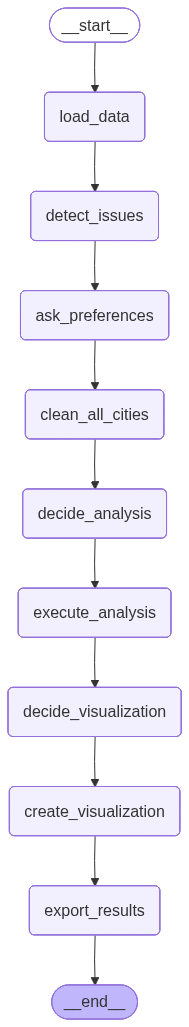

In [105]:
# 📊 Visualize the graph
display(Image(agent.get_graph().draw_mermaid_png()))

---
## Part 5: Run the Agent!

In [106]:
# 🚀 Start the agent with multiple cities!
initial_state = {
    "cities_to_analyze": ["Athens", "Barcelona", "Berlin"],
    "city_datasets": {},
    "cleaning_actions": [],
    "user_preferences": [],
    "preferences_collected": False
}

thread_id = f"airbnb_{uuid.uuid4()}"
config = {"configurable": {"thread_id": thread_id}}

print(f"🏠 Starting Airbnb Analysis Agent...")
print(f"   Thread ID: {thread_id}")
print(f"   Cities: {initial_state['cities_to_analyze']}")
print()

result = agent.invoke(initial_state, config)

🏠 Starting Airbnb Analysis Agent...
   Thread ID: airbnb_1a56352f-720c-4c97-b64d-492c2ad8a92a
   Cities: ['Athens', 'Barcelona', 'Berlin']

📂 Loading Airbnb data from multiple cities...
   ✓ Athens: 15,584 listings loaded
   ✓ Barcelona: 19,410 listings loaded
   ✓ Berlin: 14,274 listings loaded

🔍 Scanning data for issues that need your input...
   Found 1 issues that need your preferences
   (Detected from Athens, will apply to all cities)

══════════════════════════════════════════════════════════════════════
👤 YOUR INPUT NEEDED — The agent is PAUSED
══════════════════════════════════════════════════════════════════════

💡 These preferences will be applied to ALL 3 cities!


In [107]:
# 👀 See what issues were detected
if "__interrupt__" in result:
    print("\n" + "🛑" * 20)
    print("\n⏸️  AGENT PAUSED — WAITING FOR YOUR PREFERENCES")
    print("\n" + "🛑" * 20)
    
    interrupt_data = result["__interrupt__"][0].value
    
    print(f"\n📋 {interrupt_data['message']}")
    print(f"💡 {interrupt_data['note']}\n")
    
    for issue in interrupt_data['issues']:
        severity_emoji = {"high": "🔴", "medium": "🟡", "low": "🟢"}[issue['severity']]
        print(f"┌{'─' * 68}┐")
        print(f"│ {severity_emoji} Issue {issue['id']}: {issue['type'].upper():<50} │")
        print(f"├{'─' * 68}┤")
        print(f"│ Column: {issue['column']:<57} │")
        print(f"│ {issue['description']:<66} │")
        print(f"├{'─' * 68}┤")
        print(f"│ OPTIONS:{'':59} │")
        for num, opt in issue['options'].items():
            print(f"│   {num}. {opt:<61} │")
        print(f"└{'─' * 68}┘")
        print()
else:
    print("\n✅ Agent completed without needing preferences!")


🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑

⏸️  AGENT PAUSED — WAITING FOR YOUR PREFERENCES

🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑🛑

📋 I found data issues across your Airbnb datasets. How should I handle each one?
💡 Your choices will be applied consistently to all 3 cities!

┌────────────────────────────────────────────────────────────────────┐
│ 🟡 Issue 0: OUTLIERS                                           │
├────────────────────────────────────────────────────────────────────┤
│ Column: price                                                     │
│ 146 extreme prices (>$602/night)                                   │
├────────────────────────────────────────────────────────────────────┤
│ OPTIONS:                                                            │
│   1. Cap at $602                                                   │
│   2. Remove outlier rows                                           │
│   3. Keep all values                                               │
└─────────────────────────────────────────────────────────

---
## 👤 Provide Your Preferences

Edit the choices below — they'll be applied to **ALL 4 cities**!

In [108]:
# ════════════════════════════════════════════════════════════════════════════
# 👤 YOUR CHOICES — Edit these to match your preferences!
# ════════════════════════════════════════════════════════════════════════════

# Look at the issues above and fill in your choices
# These will be applied to ALL cities consistently!

my_preferences = {
    "preferences": [
        {"issue_id": 0, "choice": "Convert to numeric (remove $ and commas)"},  # Price format
        {"issue_id": 1, "choice": "Fill with median"},        # Missing bedrooms
        {"issue_id": 2, "choice": "Fill with median"},        # Missing beds  
        {"issue_id": 3, "choice": "Leave empty"},             # Missing ratings
        {"issue_id": 4, "choice": "Convert to True/False"},   # Superhost flag
        {"issue_id": 5, "choice": "Keep all values"},         # Outliers
    ]
}

print("📝 Your preferences (will apply to ALL cities):")
for p in my_preferences["preferences"]:
    print(f"   Issue {p['issue_id']}: {p['choice']}")

📝 Your preferences (will apply to ALL cities):
   Issue 0: Convert to numeric (remove $ and commas)
   Issue 1: Fill with median
   Issue 2: Fill with median
   Issue 3: Leave empty
   Issue 4: Convert to True/False
   Issue 5: Keep all values



══════════════════════════════════════════════════════════════════════
▶️  RESUMING AGENT WITH YOUR PREFERENCES
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
👤 YOUR INPUT NEEDED — The agent is PAUSED
══════════════════════════════════════════════════════════════════════

💡 These preferences will be applied to ALL 3 cities!
   ✓ price: Convert to numeric (remove $ and commas)

   ✅ Received 1 preferences (will apply to all cities!)

🧹 Applying your preferences to ALL cities...

   Processing Athens...
      Applied 0 actions, 15,584 rows remaining

   Processing Barcelona...
      Applied 0 actions, 19,410 rows remaining

   Processing Berlin...
      Applied 0 actions, 14,274 rows remaining

🧠 LLM is deciding what analytics to generate...

   📊 Decided task: Multi-City Room Type Pricing Analysis
   📝 Analyze average prices by room type (entire home, private room, shared room) across all th

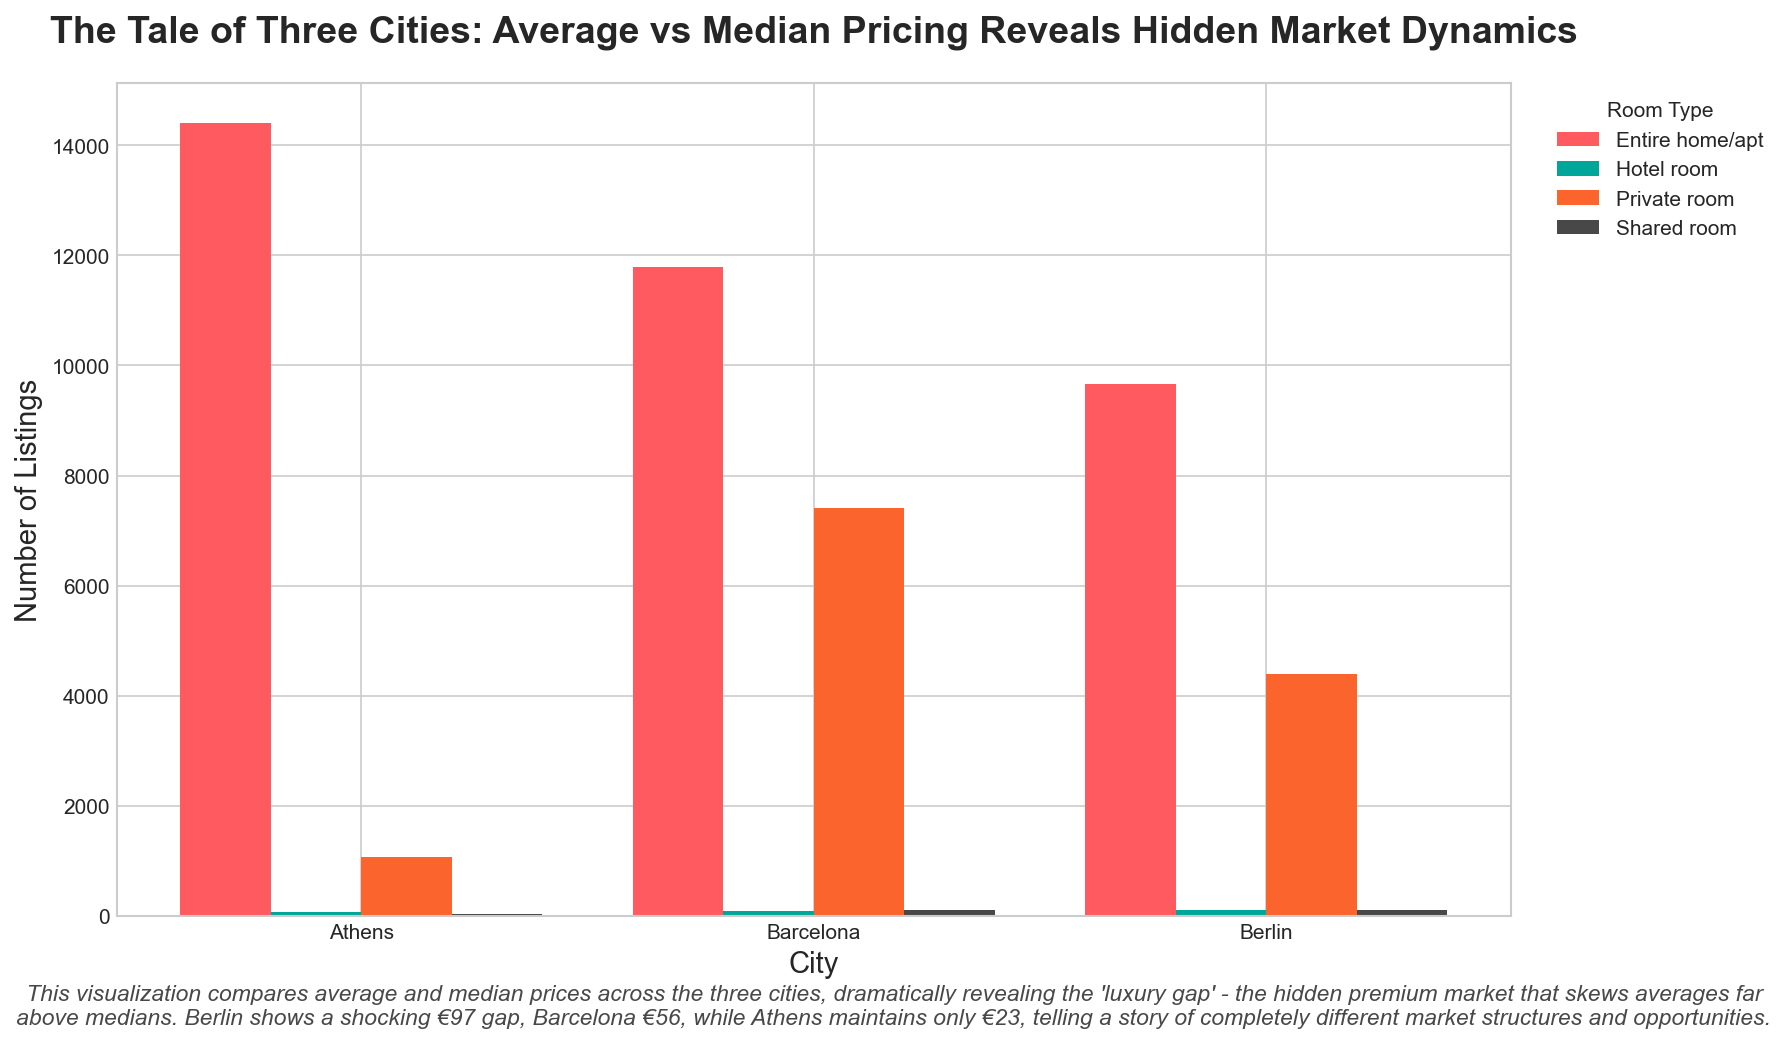


🏙️ CITIES ANALYZED: ['Athens', 'Barcelona', 'Berlin']
   • Athens: 15,584 listings
   • Barcelona: 19,410 listings
   • Berlin: 14,274 listings

🧹 CLEANING ACTIONS (0 total)

👤 YOUR PREFERENCES (applied to ALL cities)
   • price: Convert to numeric (remove $ and commas)

══════════════════════════════════════════════════════════════════════
✅ Done! Preferences applied consistently. LLM chose analysis AND visualization.
══════════════════════════════════════════════════════════════════════

🎉 Workflow complete!


In [109]:
# 🚀 Resume the agent with your preferences!

print("\n" + "═" * 70)
print("▶️  RESUMING AGENT WITH YOUR PREFERENCES")
print("═" * 70)

human_response = Command(resume=my_preferences)
final_result = agent.invoke(human_response, config)

print("\n🎉 Workflow complete!")

---
## 🔬 Inspect Results

In [110]:
# View detailed results
if final_result.get("analysis_results"):
    print("📊 ANALYSIS RESULTS\n")
    
    # City stats
    print("City-Level Statistics:")
    stats_df = pd.DataFrame(final_result["analysis_results"]["city_stats"])
    display(stats_df.T)
    
    # Room breakdown
    print("\nRoom Type Distribution:")
    room_df = pd.DataFrame(final_result["analysis_results"]["room_breakdown"])
    display(room_df)

📊 ANALYSIS RESULTS

City-Level Statistics:


,Athens,Barcelona,Berlin
listings,15584.00,19410.00,14274.00
avg_price,122.90,187.31,201.24
median_price,78.00,131.00,104.00
total_reviews,874286.00,1019270.00,635471.00
avg_availability,247.46,195.09,146.83



Room Type Distribution:


,Entire home/apt,Hotel room,Private room,Shared room
Athens,14414,62,1068,40
Barcelona,11789,94,7417,110
Berlin,9663,110,4399,102


In [111]:
# Preview cleaned data for one city
if final_result.get("city_datasets"):
    city = list(final_result["city_datasets"].keys())[0]
    city_data = final_result["city_datasets"][city]
    
    if city_data.get("cleaned_data"):
        cleaned_df = pd.read_csv(pd.io.common.StringIO(city_data["cleaned_data"]))
        print(f"📊 Cleaned Data Preview ({city}):")
        display(cleaned_df.head(10))
        
        print(f"\n📈 Quick Stats:")
        print(f"   Rows: {len(cleaned_df):,}")
        print(f"   Avg price: ${cleaned_df['price'].mean():.2f}")

📊 Cleaned Data Preview (Athens):


,id,name,host_name,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,availability_365,city
0,27262,"AQA-No7, Great mattress, high speed internet",Emmanouil,37.98924,23.76500,Entire home/apt,NaN,1,29,0,Athens
1,33945,Spacious Cosy aprtm very close to Metro!,Katerina,38.00673,23.72775,Entire home/apt,45.0,4,89,269,Athens
2,49489,Ermou 44 - 3bdr apt in the heart of Athens,Stathis,37.97670,23.73064,Entire home/apt,160.0,2,142,72,Athens
3,60394,Cosy apartment! Great central Athens location!,Dimitra,37.96738,23.74038,Entire home/apt,50.0,6,37,54,Athens
4,134340,Neo Pagrati Athens Apartment,Konstantinos,37.96405,23.74968,Entire home/apt,NaN,3,61,0,Athens
5,154243,LUSCIOUS ROOF GARDEN IN THE CENTER!,Yagos,37.98574,23.73323,Entire home/apt,70.0,2,225,347,Athens
6,155654,"Acropolis Cosy Apartment, Koukaki",Nikos,37.96828,23.72906,Entire home/apt,57.0,2,65,0,Athens
7,270611,An Oasis in the Heart of Athens,Paul,37.98586,23.72432,Entire home/apt,NaN,3,46,364,Athens
8,306234,Athens AVATON - Parthenon Suite,Agis,37.97851,23.72479,Entire home/apt,400.0,2,728,276,Athens
9,308157,#AH32 Grey studio,Flavia,37.98729,23.74311,Entire home/apt,54.0,5,2,210,Athens



📈 Quick Stats:
   Rows: 15,584
   Avg price: $122.90


---
## 🔁 Reuse Preferences for New Data

**This is the real power!** Once you've set preferences, you can add more cities or process updated data with the same cleaning rules.

In [112]:
# 💾 Save your preferences for future use
if final_result.get("user_preferences"):
    with open("airbnb_cleaning_preferences.json", "w") as f:
        json.dump({
            "preferences": final_result["user_preferences"],
            "created_from_cities": list(final_result["city_datasets"].keys()),
            "thread_id": thread_id
        }, f, indent=2)
    
    print("💾 Preferences saved to: airbnb_cleaning_preferences.json")
    print("\n📋 Your saved preferences:")
    for pref in final_result["user_preferences"]:
        print(f"   • {pref['column']}: {pref['choice']}")
    
    print("\n💡 You can now load these and apply to new cities!")

💾 Preferences saved to: airbnb_cleaning_preferences.json

📋 Your saved preferences:
   • price: Convert to numeric (remove $ and commas)

💡 You can now load these and apply to new cities!


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('422 Client Error: unknown for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unprocessable entity: error reading multipart data: multipart: NextPart: failed to decompress: Unknown frame descriptor"}\n')


---
## 📚 Key Takeaways

### What You Built

1. **Multi-Dataset Processing** — Load and process 4 cities in one workflow
2. **Shared Preferences** — Ask once, apply to all (impossible in Cursor!)
3. **Autonomous Analysis** — LLM decides what analytics to generate
4. **Autonomous Visualization** — LLM decides the most impactful chart for your audience
5. **Persistent State** — Resume anytime, even after kernel restart

### The Workflow

```
Load 4 Cities → Detect Issues → Ask YOUR Preferences → Clean ALL → LLM Decides Task → Analyze → LLM Picks Viz → Create Chart → Report
```

### Why This Matters

| Manual Approach | Your Agent |
|----------------|-------------|
| Clean each city separately | One preference, all cities |
| Decide analysis yourself | LLM suggests best analysis |
| Create charts manually | LLM picks the most impactful viz |
| Repeat for new data | Saved preferences, instant apply |
| No audit trail | Full traceability |

---

<div style="background: linear-gradient(135deg, #FF5A5F 0%, #00A699 100%); padding: 20px; border-radius: 10px; color: white; text-align: center;">
    <h3 style="color: white;">🎉 Congratulations!</h3>
    <p>You built a <strong>multi-city, preference-aware, autonomous analysis agent</strong> for Airbnb data!</p>
    <p>Your agent asks for preferences ONCE, applies them to ALL cities, lets the LLM decide what to analyze, AND automatically creates the most impactful visualization for your presentation!</p>
</div>